This notebook contains code to demonstrate how to use the model for inference and detect the Atmospheric Rivers (ARs).

In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from deep_ar.data.datasets import ARInferenceDataset

In [5]:
dataset = ARInferenceDataset(input_files=["IVT_yearly_2020.nc"], ivt_vars= ("ivt", "ivtu", "ivtv"))

Opening dataset files with memory mapping...
Building dataset index...
Dataset ready with 316 samples.


In [8]:
model = deep_ar_model_registry["vit_l"](checkpoint="./best_model_batch56.pth")

Loading model from ./best_model_batch56.pth


In [9]:
import torch

# Put model in eval mode
model.eval()

# Get an image from the dataset and add a batch dimension
image = dataset[0]["image"].unsqueeze(0)

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
image = image.to(device)

# Run inference
with torch.no_grad():
    predictions = model(image, return_intermediate=True)

print(predictions["output"].shape)

torch.Size([1, 1, 360, 720])


In [10]:
prediction = predictions["output"].squeeze().cpu().numpy()

In [11]:
import xarray as xr
# Get the coordinates from the original netCDF file
ds = xr.open_dataset("IVT_yearly_2020.nc")
# The dimension names are usually 'latitude' and 'longitude' or 'lat' and 'lon'
lats = ds.latitude.values if 'latitude' in ds else ds.lat.values
lons = ds.longitude.values if 'longitude' in ds else ds.lon.values

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Visualizing the AR maps predicted by the model.

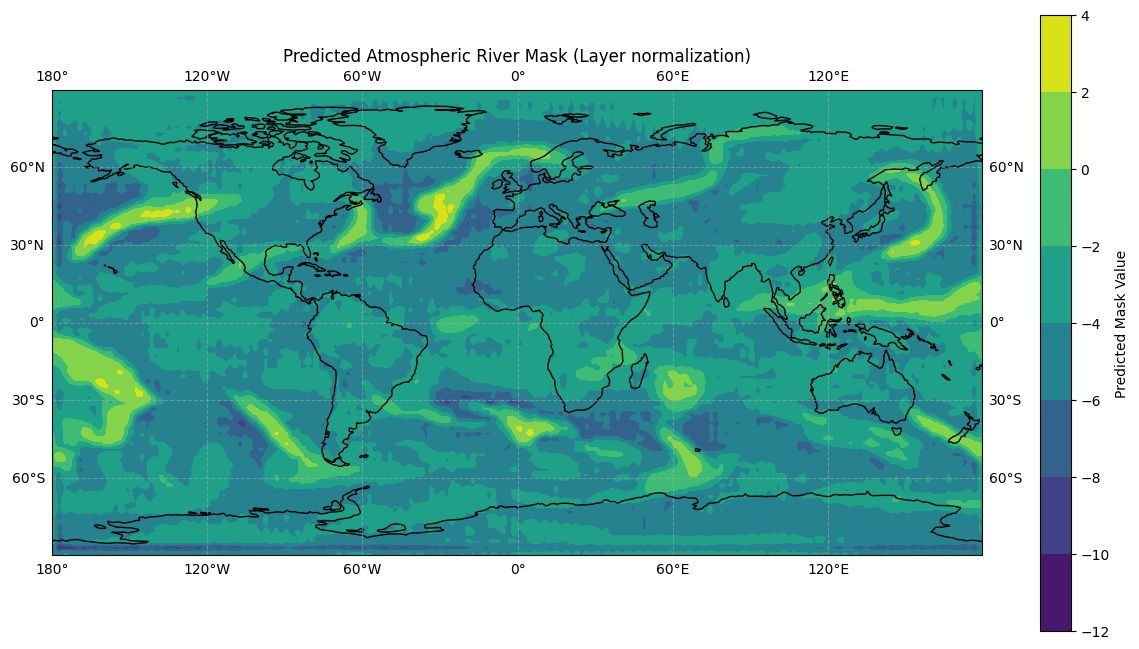

In [13]:
# Set up the plot with Cartopy
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastline and borders for reference
ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

contour = ax.contourf(lons, lats, predictions["output"].squeeze(), 
                      transform=ccrs.PlateCarree(), cmap='viridis')

plt.title("Predicted Atmospheric River Mask (Layer normalization)")
plt.colorbar(contour, ax=ax, orientation='vertical', label='Predicted Mask Value')
plt.savefig("layer_normalization.png", dpi=300)
plt.show()

In [21]:
# Visualize the input image
image = predictions["input_features"].squeeze().cpu().numpy()

In [22]:
image.shape

(3, 360, 720)

# Visualizing the image given as output by the CNN network (IVT2RGB)
This image is then given as input the Image Encoder of the model to predict the AR maps.

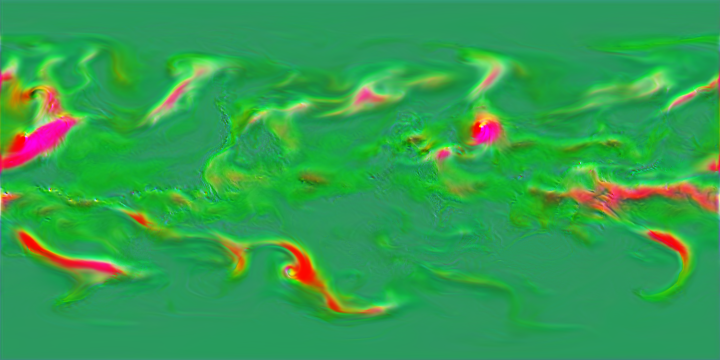

In [23]:
import numpy as np
from PIL import Image
from IPython.display import display

img_array = image.copy()

# PyTorch tensors are typically (C, H, W). PIL expects (H, W, C).
if img_array.ndim == 3 and img_array.shape[0] == 3:
    img_array = np.transpose(img_array, (1, 2, 0))

# Convert directly to uint8 as required by PIL for RGB images
if img_array.dtype != np.uint8:
    # If the network output happens to be float [0, 1], scale it to [0, 255]
    img_array = img_array.astype(np.uint8)

pil_image = Image.fromarray(img_array)
display(pil_image)

In [24]:
pil_image.save("input_image.png", dpi=(300, 300))